In [2]:
import pandas as pd
import unicodedata

input_path = "ekstraklasa_1989_2023.csv"
output_path = "ekstraklasa_1989_2023_normalized.csv"

df = pd.read_csv(input_path)

def strip_accents(text):
    if pd.isna(text):
        return text
    text = unicodedata.normalize('NFKD', text)
    return ''.join(c for c in text if not unicodedata.combining(c))

for col in df.columns:
    if df[col].dtype == object:
        df[col] = df[col].apply(strip_accents)

rename_map = {
    "data": "date",
    "godzina": "time",
    "dom": "home_team",
    "wyjazd": "away_team",
    "wynik": "score"
}

df = df.rename(columns=rename_map)

df[["home_goals", "away_goals"]] = df["score"].str.split(":", expand=True).astype(int)

df = df.drop(columns=["score", "Unnamed: 0", "time"])

df.to_csv(output_path, index=False)

In [3]:
#2. Wczytywanie danych

In [4]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, log_loss
#import matplotlib.pyplot as plt

df = pd.read_csv("ekstraklasa_1989_2023_normalized.csv", parse_dates=["date"])
df = df.sort_values("date").reset_index(drop=True)

df.head()

,date,home_team,away_team,home_goals,away_goals
0,1989-07-29,GKS Katowice,ŁKS Łodz,0,1
1,1989-07-29,Motor Lublin,Widzew Łodz,2,0
2,1989-07-29,Ruch Chorzow,Gornik Zabrze,2,0
3,1989-07-29,Legia Warszawa,FKS Stal Mielec,1,1
4,1989-07-29,Zawisza Bydgoszcz,Slask Wrocław,1,0


In [5]:
#3. Tworzenie 2 rekordów dla każdego meczu

In [6]:
def expand_matches_to_teams(df):
    rows = []

    for _, r in df.iterrows():
        # HOME TEAM
        rows.append({
            "date": r["date"],
            "team": r["home_team"],
            "opponent": r["away_team"],
            "is_home": 1,
            "goals_for": r["home_goals"],
            "goals_against": r["away_goals"],
        })

        # AWAY TEAM
        rows.append({
            "date": r["date"],
            "team": r["away_team"],
            "opponent": r["home_team"],
            "is_home": 0,
            "goals_for": r["away_goals"],
            "goals_against": r["home_goals"],
        })

    df_long = pd.DataFrame(rows)

    # target
    df_long["result"] = np.where(
        df_long["goals_for"] > df_long["goals_against"], 0,
        np.where(df_long["goals_for"] == df_long["goals_against"], 1, 2)
    )

    return df_long

df_long = expand_matches_to_teams(df)
df_long.head(6)

,date,team,opponent,is_home,goals_for,goals_against,result
0,1989-07-29,GKS Katowice,ŁKS Łodz,1,0,1,2
1,1989-07-29,ŁKS Łodz,GKS Katowice,0,1,0,0
2,1989-07-29,Motor Lublin,Widzew Łodz,1,2,0,0
3,1989-07-29,Widzew Łodz,Motor Lublin,0,0,2,2
4,1989-07-29,Ruch Chorzow,Gornik Zabrze,1,2,0,0
5,1989-07-29,Gornik Zabrze,Ruch Chorzow,0,0,2,2


In [7]:
#3. Rolling features

In [8]:
def add_team_rolling_features(df, window=5):
    df = df.sort_values("date")

    df["gf_roll"] = (
        df.groupby("team")["goals_for"]
        .rolling(window, min_periods=1)
        .mean()
        .shift(1)
        .reset_index(level=0, drop=True)
    )

    df["ga_roll"] = (
        df.groupby("team")["goals_against"]
        .rolling(window, min_periods=1)
        .mean()
        .shift(1)
        .reset_index(level=0, drop=True)
    )

    df["pts"] = np.where(
        df["goals_for"] > df["goals_against"], 3,
        np.where(df["goals_for"] == df["goals_against"], 1, 0)
    )

    df["pts_roll"] = (
        df.groupby("team")["pts"]
        .rolling(window, min_periods=1)
        .mean()
        .shift(1)
        .reset_index(level=0, drop=True)
    )

    return df

df = add_team_rolling_features(df_long)
df.head()

,date,team,opponent,is_home,goals_for,goals_against,result,gf_roll,ga_roll,pts,pts_roll
0,1989-07-29,GKS Katowice,ŁKS Łodz,1,0,1,2,2.0,3.0,0,0.8
15,1989-07-29,Jagiellonia Białystok,Zagłebie Sosnowiec,0,1,1,1,0.8,3.2,1,0.0
14,1989-07-29,Zagłebie Sosnowiec,Jagiellonia Białystok,1,1,1,1,1.4,1.0,1,2.0
13,1989-07-29,Lech Poznan,Zagłebie Lubin,0,0,2,2,1.4,1.2,0,1.6
12,1989-07-29,Zagłebie Lubin,Lech Poznan,1,2,0,0,0.4,2.0,3,0.2


In [9]:
#4. ELO

In [10]:
def add_elo_team_centric(df, k=30):
    elos = {}
    df["elo"] = np.nan

    for i, r in df.iterrows():
        team = r["team"]
        opp = r["opponent"]

        elos.setdefault(team, 1500)
        elos.setdefault(opp, 1500)

        df.at[i, "elo"] = elos[team]

        if r["result"] == 1:
            res = 1
        elif r["result"] == 0:
            res = 0.5
        else:
            res = 0

        exp = 1 / (1 + 10 ** ((elos[opp] - elos[team]) / 400))
        elos[team] += k * (res - exp)
        elos[opp] += k * ((1 - res) - (1 - exp))

    return df

df = add_elo_team_centric(df)

df_cp = df
df.head()

,date,team,opponent,is_home,goals_for,goals_against,result,gf_roll,ga_roll,pts,pts_roll,elo
0,1989-07-29,GKS Katowice,ŁKS Łodz,1,0,1,2,2.0,3.0,0,0.8,1500.0
15,1989-07-29,Jagiellonia Białystok,Zagłebie Sosnowiec,0,1,1,1,0.8,3.2,1,0.0,1500.0
14,1989-07-29,Zagłebie Sosnowiec,Jagiellonia Białystok,1,1,1,1,1.4,1.0,1,2.0,1485.0
13,1989-07-29,Lech Poznan,Zagłebie Lubin,0,0,2,2,1.4,1.2,0,1.6,1500.0
12,1989-07-29,Zagłebie Lubin,Lech Poznan,1,2,0,0,0.4,2.0,3,0.2,1515.0


In [11]:
#5. testowanie modelu poissona

In [12]:
import statsmodels.api as sm

features = ["is_home", "elo", "gf_roll", "ga_roll", "pts_roll"]
X = df[features]
X = sm.add_constant(X)
y = df["goals_for"]

X.isna().sum().sort_values(ascending=False)
np.isinf(X).sum()

mask = X.notna().all(axis=1)
X_clean = X[mask]
y_clean = y[mask]

X_clean = sm.add_constant(X_clean)

poisson_model = sm.GLM(
    y_clean,
    X_clean,
    family=sm.families.Poisson()
).fit()

print(poisson_model.summary())


                 Generalized Linear Model Regression Results                  
Dep. Variable:              goals_for   No. Observations:                18209
Model:                            GLM   Df Residuals:                    18203
Model Family:                 Poisson   Df Model:                            5
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -25870.
Date:                Sat, 17 Jan 2026   Deviance:                       21352.
Time:                        19:09:34   Pearson chi2:                 1.87e+04
No. Iterations:                     5   Pseudo R-squ. (CS):            0.09574
Covariance Type:            nonrobust                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -8.4094      0.304    -27.686      0.0

In [13]:
#Model Poissona jest dobrze dopasowany i statystycznie stabilny (brak overdispersion, sensowne pseudo-R² jak na piłkę nożną).
#Efekt własnego boiska jest silny (~+41% goli), a ELO i forma strzelecka (gf_roll) dodatnio i istotnie wpływają na liczbę goli,
#co jest zgodne z intuicją. Zmienna ga_roll działa w oczekiwanym kierunku, natomiast pts_roll ma ujemny wpływ,
#prawdopodobnie z powodu kolinearności lub defensywnego stylu drużyn zdobywających punkty.

In [14]:
#6. Dwa modele Poissona (home, away)

In [15]:
df_home = df[df["is_home"] == 1].copy()
df_away = df[df["is_home"] == 0].copy()

features = ["elo", "gf_roll", "ga_roll"]

# HOME model
Xh = df_home[features]
yh = df_home["goals_for"]

mask = Xh.notna().all(axis=1)
Xh = sm.add_constant(Xh[mask])
yh = yh[mask]

home_model = sm.GLM(yh, Xh, family=sm.families.Poisson()).fit()

# AWAY model (is_home = 0)
Xa = df_away[features]
ya = df_away["goals_for"]

mask = Xa.notna().all(axis=1)
Xa = sm.add_constant(Xa[mask])
ya = ya[mask]

away_model = sm.GLM(ya, Xa, family=sm.families.Poisson()).fit()

print(Xa)


       const          elo  gf_roll  ga_roll
15       1.0  1500.000000      0.8      3.2
13       1.0  1500.000000      1.4      1.2
9        1.0  1500.000000      1.0      2.2
11       1.0  1485.000000      1.4      1.4
5        1.0  1500.000000      0.8      0.4
...      ...          ...      ...      ...
18197    1.0  1509.428822      2.0      1.6
18199    1.0  1547.396192      1.0      1.0
18207    1.0  1520.460804      0.8      1.8
18205    1.0  1571.973461      2.4      1.4
18209    1.0  1610.543844      2.4      1.4

[9105 rows x 4 columns]


In [16]:
#7. Predykcja lambda_home i lambda_away dla jednego meczu

In [17]:
match_home = df_home.iloc[[0]]
match_away = df_away.iloc[[0]]

#lamda_home
Xh_match = sm.add_constant(match_home[features], has_constant="add")
lambda_home = home_model.predict(Xh_match).iloc[0]
print(lambda_home)

#lamda_away
Xa_match = sm.add_constant(match_away[features], has_constant="add")
lambda_away = away_model.predict(Xa_match).iloc[0]
print(lambda_away)


1.3501622581170816
0.9325777268917237


In [18]:
#10. Macierz wyników

In [19]:
import numpy as np
from scipy.stats import poisson

max_goals = 6  

P = np.zeros((max_goals+1, max_goals+1))

for i in range(max_goals+1):
    for j in range(max_goals+1):
        P[i, j] = poisson.pmf(i, lambda_home) * poisson.pmf(j, lambda_away)

p_home = np.tril(P, -1).sum()  
p_draw = np.trace(P)           
p_away = np.triu(P, 1).sum()   

print(p_home + p_draw + p_away)

print(f"P(Home win): {p_home:.3f}")
print(f"P(Draw):     {p_draw:.3f}")
print(f"P(Away win): {p_away:.3f}")


0.9994419944412342
P(Home win): 0.464
P(Draw):     0.277
P(Away win): 0.259


In [20]:
#11. Funkcja lambda_home/away -> P(1X2)

In [21]:
from scipy.stats import poisson
import numpy as np


def poisson_1x2(lambda_home, lambda_away, max_goals=6):
    P = np.zeros((max_goals+1, max_goals+1))
    for i in range(max_goals+1):
        for j in range(max_goals+1):
            P[i, j] = poisson.pmf(i, lambda_home) * poisson.pmf(j, lambda_away)

    p_home = np.tril(P, -1).sum()
    p_draw = np.trace(P)
    p_away = np.triu(P, 1).sum()

    return p_home, p_draw, p_away

In [22]:
#12. Iteracja po meczach

In [23]:
rows = []

df_cp["match_key"] = df_cp.apply(
    lambda r: "_".join(sorted([r["team"], r["opponent"]])),
    axis=1
)

df_cp["match_id"] = df_cp.groupby(["date", "match_key"]).ngroup()

df_cp.groupby("match_id").size().value_counts()

for match_id, g in df.groupby("match_id"):
    if len(g) != 2:
        continue

    home = g[g["is_home"] == 1]
    away = g[g["is_home"] == 0]

    if home.empty or away.empty:
        continue

    Xh = sm.add_constant(home[features], has_constant="add")
    Xa = sm.add_constant(away[features], has_constant="add")

    Xh = Xh.fillna(0)
    Xa = Xa.fillna(0)

    lambda_home = home_model.predict(Xh).iloc[0]
    lambda_away = away_model.predict(Xa).iloc[0]

    p1, px, p2 = poisson_1x2(lambda_home, lambda_away)

    rows.append({
        "match_id": match_id,
        "date": home["date"].iloc[0],
        "home_team": home["team"].iloc[0],
        "away_team": away["team"].iloc[0],
        "lambda_home": lambda_home,
        "lambda_away": lambda_away,
        "p_home": p1,
        "p_draw": px,
        "p_away": p2,
    })

pred_df = pd.DataFrame(rows)
pred_df[["p_home","p_draw","p_away"]].sum(axis=1).describe()
pred_df.head()

,match_id,date,home_team,away_team,lambda_home,lambda_away,p_home,p_draw,p_away
0,0,1989-07-29,Legia Warszawa,FKS Stal Mielec,1.318835,0.784846,0.492167,0.284985,0.222391
1,1,1989-07-29,GKS Katowice,ŁKS Łodz,1.350162,0.933120,0.463521,0.276978,0.258943
2,2,1989-07-29,Ruch Chorzow,Gornik Zabrze,1.270338,0.831867,0.466255,0.289701,0.243665
3,3,1989-07-29,Zagłebie Sosnowiec,Jagiellonia Białystok,1.074352,0.932578,0.383517,0.306788,0.309512
4,4,1989-07-29,Zagłebie Lubin,Lech Poznan,1.425166,0.856701,0.502948,0.270366,0.225963


In [ ]:
#13. Sprawdzanie poprawności predykcji

In [24]:
pred_df[["p_home","p_draw","p_away"]].sum(axis=1).describe()

count    9105.000000
mean        0.998289
std         0.002673
min         0.953981
25%         0.998132
50%         0.999134
75%         0.999562
max         0.999989
dtype: float64

In [25]:
#Średnia suma = 0.9983 → bardzo dobra aproksymacja (ucięcie na max_goals=6 działa OK), brak wartości większych od 1 model probabilistyczny
#działa okej

In [ ]:
#14 Metryki dla Poissona (y_true, y_pred) - Accuracy, LogLoss, Brier

In [26]:
from sklearn.metrics import log_loss, accuracy_score
import numpy as np

# prawdziwy wynik meczu (jeden wiersz / mecz)
y_true = (
    df_cp[df_cp["is_home"] == 1]
    .sort_values("match_id")
    ["result"]
    .values
)

# prawdopodobieństwa Poissona
P_poisson = (
    pred_df
    .sort_values("match_id")[["p_home", "p_draw", "p_away"]]
    .values
)

y_pred_poisson = np.argmax(P_poisson, axis=1)
acc_poisson = accuracy_score(y_true, y_pred_poisson)

ll_poisson = log_loss(y_true, P_poisson)

def multiclass_brier(y_true, probs):
    y_onehot = np.zeros_like(probs)
    y_onehot[np.arange(len(y_true)), y_true] = 1
    return np.mean(np.sum((probs - y_onehot) ** 2, axis=1))

brier_poisson = multiclass_brier(y_true, P_poisson)

print(f"Poisson | Accuracy: {acc_poisson:.3f}")
print(f"Poisson | LogLoss : {ll_poisson:.3f}")
print(f"Poisson | Brier   : {brier_poisson:.3f}")


Poisson | Accuracy: 0.498
Poisson | LogLoss : 1.005
Poisson | Brier   : 0.600


C:\Users\anton\anaconda3\envs\mlbet\lib\site-packages\sklearn\metrics\_classification.py:259: UserWarning: The y_prob values do not sum to one. Make sure to pass probabilities.
  warnings.warn(


In [27]:
#Tabele porównawcze LG, RF, XGB, Poisson

In [29]:
#wyniki wzięte z pierwszego notebooka
acc_lg= 0.465934
ll_lg=1.034048
brier_lg=0.623907
acc_rf= 0.462637
ll_rf=1.039244
brier_rf=0.626699
acc_xgb= 0.462363
ll_xgb=1.041467
brier_xgb=0.628367

results = pd.DataFrame({
    "Model": ["Poisson", "Logistic", "RandomForrest", "XGBoost"],
    "Accuracy": [acc_poisson, acc_lg, acc_rf, acc_xgb],
    "LogLoss": [ll_poisson, ll_lg, ll_rf, ll_xgb],
    "Brier": [brier_poisson, brier_lg, brier_rf, brier_xgb],
})

results

,Model,Accuracy,LogLoss,Brier
0,Poisson,0.498407,1.004629,0.600190
1,Logistic,0.465934,1.034048,0.623907
2,RandomForrest,0.462637,1.039244,0.626699
3,XGBoost,0.462363,1.041467,0.628367


In [30]:
#Wykres porównawczy

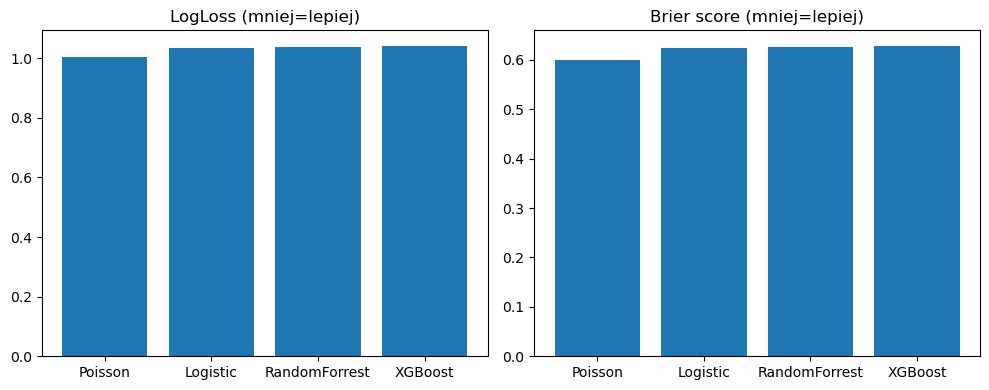

In [35]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(1, 2, figsize=(10, 4))

ax[0].bar(results["Model"], results["LogLoss"])
ax[0].set_title("LogLoss (mniej=lepiej)")

ax[1].bar(results["Model"], results["Brier"])
ax[1].set_title("Brier score (mniej=lepiej)")

plt.tight_layout()
plt.show()


In [33]:
#Model Poissona wygrywa we wszystkich trzech metrykach.
#Ma najwyższą accuracy (~49.8%), najniższy log-loss (1.00) i zdecydowanie najlepszy Brier (0.60),
#co oznacza najlepszą kalibrację prawdopodobieństw. Logistic jest wyraźnie drugi,
#a modele drzewiaste (RF, XGB) mimo większej złożoności nie generalizują lepiej i są gorzej skalibrowane.
# w kontekście bettingu poisson ma najlepszy potencjał na bycie modelem produkcyjnym. Zanim to nastąpi można pokusić się o kalibrację
#XGB i RF żeby zobaczyć gdzie się myli (ensemble i calibration plot)